# Exploratory Data Analysis (EDA) Project

## 1. Project Introduction

### Project Overview
This project aims to perform an Exploratory Data Analysis (EDA) on a real-world dataset. EDA is a crucial step in any data science project, allowing us to understand the data's characteristics, identify patterns, detect anomalies, and formulate hypotheses. The insights gained from EDA will guide subsequent data cleaning, preprocessing, and modeling phases.

### Problem Statement
To uncover hidden patterns, trends, and relationships within the chosen dataset that can provide valuable business insights. By thoroughly exploring the data, we seek to answer specific questions, validate assumptions, and identify potential areas for further investigation or improvement.

### Objectives
*   **Understand Data Structure**: Examine the dataset's composition, including its dimensions, column names, and data types.
*   **Identify Data Quality Issues**: Detect missing values, duplicates, and inconsistencies that may affect analysis.
*   **Explore Data Distributions**: Visualize the distribution of individual variables to understand their central tendency, spread, and shape.
*   **Analyze Relationships**: Investigate correlations and relationships between different variables.
*   **Discover Patterns and Trends**: Identify significant patterns, trends, or outliers that provide actionable insights.
*   **Formulate Business Insights**: Translate data observations into meaningful business recommendations.

### Dataset Description
For this project, we will be using the **Netflix Movies and TV Shows dataset**. This dataset contains a comprehensive list of movies and TV shows available on Netflix, along with various attributes such as title, director, cast, country, release year, rating, duration, and listed genres. This dataset is excellent for exploring content trends, geographical distribution of productions, and popular genres.

### Expected Outcome
By the end of this EDA project, we expect to have:
*   A clear understanding of the Netflix content library.
*   Insights into popular genres, directors, and actors.
*   Patterns related to content production over time and across different countries.
*   Key findings and business recommendations that can inform content acquisition strategies or audience targeting.

## 2. Import Libraries

In this section, we will import all the necessary Python libraries required for data manipulation, analysis, and visualization. Each library plays a specific role in our EDA process.

In [1]:
# Import the pandas library for data manipulation and analysis.
import pandas as pd

# Import the numpy library for numerical operations, especially with arrays.
import numpy as np

# Import matplotlib.pyplot for creating static, interactive, and animated visualizations.
import matplotlib.pyplot as plt

# Import seaborn for statistical data visualization, built on top of matplotlib.
import seaborn as sns

# Set default style for seaborn plots
sns.set_style('whitegrid')

## 3. Load Dataset

To begin our analysis, we need to load the dataset into a pandas DataFrame. This project uses the 'Netflix Movies and TV Shows' dataset, which is typically available as a CSV file. You will need to upload this CSV file to your Colab environment or provide its path if it's hosted online.

**Instructions for uploading the CSV file:**
1.  Click on the folder icon on the left sidebar (File Browser).
2.  Click on the 'Upload to session storage' icon.
3.  Select your `netflix_titles.csv` file.

Once uploaded, we will load it and display some initial information to get a first glance at the data.

### Downloading Dataset from Kaggle

Since we are using the Netflix Movies and TV Shows dataset from Kaggle, we'll download it programmatically. This requires the `kaggle` library and your Kaggle API credentials.

**Steps to prepare your Kaggle API key:**
1.  Go to Kaggle.com and log in.
2.  Navigate to 'My Account' (`kaggle.com/me/account`).
3.  In the 'API' section, click 'Create New API Token' to download `kaggle.json`.
4.  Upload this `kaggle.json` file to your Google Colab session. Click the folder icon on the left sidebar (File Browser) > 'Upload to session storage' icon > select `kaggle.json`.

In [4]:
# Install the Kaggle library
!pip install kaggle

# Make a directory for Kaggle credentials if it doesn't exist
!mkdir -p ~/.kaggle

# Move the uploaded kaggle.json file to the correct directory
# This assumes you have uploaded 'kaggle.json' to the Colab session root
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file (important for security)
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API setup complete. You can now download datasets.")

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API setup complete. You can now download datasets.


In [5]:
# Download the Netflix Movies and TV Shows dataset from Kaggle
# The dataset name is 'shivamb/netflix-shows'
!kaggle datasets download -d shivamb/netflix-shows

# Unzip the downloaded dataset
# The downloaded file is usually a .zip file (e.g., netflix-shows.zip)
!unzip netflix-shows.zip

print("Dataset downloaded and extracted successfully!")

# Verify the extracted files
!ls

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
100% 1.34M/1.34M [00:00<00:00, 77.4MB/s]

Archive:  netflix-shows.zip
  inflating: netflix_titles.csv      
Dataset downloaded and extracted successfully!
netflix-shows.zip  netflix_titles.csv  sample_data


In [6]:
# Load the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('netflix_titles.csv')

# Display the first 5 rows of the DataFrame to get a quick overview of the data
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display the last 5 rows of the DataFrame
print("\nLast 5 rows of the dataset:")
display(df.tail())

# Display the shape of the DataFrame (number of rows, number of columns)
print("\nShape of the dataset (rows, columns):")
print(df.shape)

# Display the column names of the DataFrame
print("\nColumn names:")
print(df.columns.tolist())

# Display the data types of each column
print("\nData types of each column:")
print(df.dtypes)

# Display a concise summary of the DataFrame, including data types and non-null values
print("\nDataset Information:")
df.info()

# Display descriptive statistics for numerical columns
print("\nStatistical Summary of Numerical Columns:")
display(df.describe())


First 5 rows of the dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Last 5 rows of the dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...



Shape of the dataset (rows, columns):
(8807, 12)

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data types of each column:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_ad

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## 4. Data Understanding

This section focuses on understanding the quality and characteristics of our dataset. We will check for common data issues like missing values and duplicate entries, and identify the types of variables present (numerical vs. categorical). This step is crucial for planning our data cleaning and preprocessing strategies.

In [7]:
# --- Checking for Missing Values ---
print("\n--- Missing Values ---")
# Calculate the percentage of missing values for each column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage': missing_percentage})
# Display columns with missing values, sorted by percentage
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage', ascending=False))

# --- Checking for Duplicate Rows ---
print("\n--- Duplicate Rows ---")
# Calculate the number of duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# --- Checking for Unique Values in Categorical Columns ---
print("\n--- Unique Values in Categorical Columns ---")
# Identify categorical columns (object type)
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"Column '{col}' has {df[col].nunique()} unique values.")
    # Display unique values if there are not too many
    if df[col].nunique() < 50:
        print(f"Unique values for '{col}': {df[col].unique()}")

# --- Identifying Numerical and Categorical Columns ---
print("\n--- Column Types ---")
# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

# Select categorical columns
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print(f"Categorical columns: {categorical_cols}")


--- Missing Values ---


,Missing Count,Percentage
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064



--- Duplicate Rows ---
Number of duplicate rows: 0

--- Unique Values in Categorical Columns ---
Column 'show_id' has 8807 unique values.
Column 'type' has 2 unique values.
Unique values for 'type': ['Movie' 'TV Show']
Column 'title' has 8807 unique values.
Column 'director' has 4528 unique values.
Column 'cast' has 7692 unique values.
Column 'country' has 748 unique values.
Column 'date_added' has 1767 unique values.
Column 'rating' has 17 unique values.
Unique values for 'rating': ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']
Column 'duration' has 220 unique values.
Column 'listed_in' has 514 unique values.
Column 'description' has 8775 unique values.

--- Column Types ---
Numerical columns: ['release_year']
Categorical columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']


### Observations from Data Understanding:

*   **Missing Values**:
    *   The `director`, `cast`, `country`, `date_added`, and `rating` columns have a significant number of missing values. These will need to be handled, potentially by imputation, removal, or careful consideration during analysis.
    *   The `duration` column also has some missing values, which might need specific handling depending on whether the content is a movie or TV show.

*   **Duplicate Rows**:
    *   There are no exact duplicate rows found, which is good for data integrity.

*   **Unique Values**:
    *   `show_id` is unique for each entry, serving as a primary identifier.
    *   `type` clearly distinguishes between 'Movie' and 'TV Show'.
    *   `release_year` and `duration` (once cleaned) will be important numerical features.
    *   `listed_in` (genres) and `description` contain rich textual information that might require text processing for deeper insights.
    *   `country` and `rating` have multiple unique values, and their distributions will be interesting to explore.

*   **Column Types**:
    *   Numerical columns are limited (`release_year` might be considered as such, depending on the analysis, but `show_id` is more of an identifier).
    *   Most other columns are categorical or object types, indicating the need for string manipulation and categorical analysis.

These observations will guide our next steps in data preprocessing and exploratory data analysis.

## 5. Exploratory Data Analysis (EDA)

In this section, we will delve into the data through various visualizations to uncover patterns, trends, and relationships. Before we plot, we'll perform some necessary data cleaning and feature engineering steps to prepare the data for effective analysis. This includes handling missing values, converting data types, and creating new features that will help us gain deeper insights.

### Data Preprocessing for EDA

Based on our data understanding, several columns require preprocessing:
*   **Handling Missing Values**: Fill `director`, `cast`, `country`, and `rating` with 'Unknown' or appropriate values.
*   **`date_added` Conversion**: Convert to datetime objects for time-series analysis.
*   **`duration` Extraction**: Extract numerical duration (minutes for movies, seasons for TV shows) for quantitative analysis.
*   **`listed_in` and `country` Expansion**: These columns contain multiple values in a single string, which need to be separated for individual analysis of genres and countries.

In [8]:
# Create a copy of the original DataFrame to perform cleaning operations
df_eda = df.copy()

# --- Handling Missing Values ---
# Fill missing 'director', 'cast', 'country', 'date_added', and 'rating' values with 'Unknown'
# For 'date_added', we will fill with a placeholder string first, then convert.
df_eda['director'].fillna('Unknown', inplace=True)
df_eda['cast'].fillna('Unknown', inplace=True)
df_eda['country'].fillna('Unknown', inplace=True)
df_eda['date_added'].fillna('Unknown', inplace=True) # Temporarily fill before conversion attempt
df_eda['rating'].fillna('Unknown', inplace=True)

# --- Convert 'date_added' to datetime ---
# Convert 'date_added' to datetime, coercing errors to NaT (Not a Time)
df_eda['date_added'] = pd.to_datetime(df_eda['date_added'], errors='coerce')
# Drop rows where 'date_added' couldn't be parsed (now NaT)
df_eda.dropna(subset=['date_added'], inplace=True)

# Extract month and year from 'date_added' for time-based analysis
df_eda['month_added'] = df_eda['date_added'].dt.month_name()
df_eda['year_added'] = df_eda['date_added'].dt.year

# --- Process 'duration' column ---
# Create 'duration_int' for numerical duration
df_eda['duration_int'] = df_eda['duration'].apply(
    lambda x: int(x.split(' ')[0]) if isinstance(x, str) and x.split(' ')[0].isdigit() else np.nan
)
# Create 'duration_type' to differentiate 'min' and 'seasons'
df_eda['duration_type'] = df_eda['duration'].apply(
    lambda x: x.split(' ')[1] if isinstance(x, str) and len(x.split(' ')) > 1 else np.nan
)

# Remove rows where 'duration_int' or 'duration_type' couldn't be parsed (e.g., '74 min' that was originally in 'rating')
df_eda.dropna(subset=['duration_int', 'duration_type'], inplace=True)

# --- Expand 'listed_in' and 'country' columns ---
# For genres ('listed_in')
df_genres = df_eda.assign(listed_in=df_eda['listed_in'].str.split(', ')).explode('listed_in')

# For countries ('country')
df_countries = df_eda.assign(country=df_eda['country'].str.split(', ')).explode('country')

print("Data preprocessing for EDA complete. Displaying info of the cleaned DataFrame:")
df_eda.info()
print("\nFirst 5 rows of the cleaned DataFrame:")
display(df_eda.head())

/tmp/ipykernel_645/4006312535.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_eda['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_645/4006312535.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

Data preprocessing for EDA complete. Displaying info of the cleaned DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 8706 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8706 non-null   object        
 1   type           8706 non-null   object        
 2   title          8706 non-null   object        
 3   director       8706 non-null   object        
 4   cast           8706 non-null   object        
 5   country        8706 non-null   object        
 6   date_added     8706 non-null   datetime64[ns]
 7   release_year   8706 non-null   int64         
 8   rating         8706 non-null   object        
 9   duration       8706 non-null   object        
 10  listed_in      8706 non-null   object        
 11  description    8706 non-null   object        
 12  month_added    8706 non-null   object        
 13  year_added     8706 non-null   int32         
 14

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,duration_int,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,2021,90.0,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,2021,2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,2021,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,2021,1.0,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,2021,2.0,Seasons


### Visualizations

Now that our data is preprocessed, we can create various visualizations to explore distributions, trends, and relationships. Each chart will be accompanied by an explanation and business insights.

#### 5.1 Content Type Distribution (Pie Chart)

This pie chart shows the proportion of 'Movie' versus 'TV Show' content on Netflix. Understanding this distribution is fundamental to grasping Netflix's content strategy.

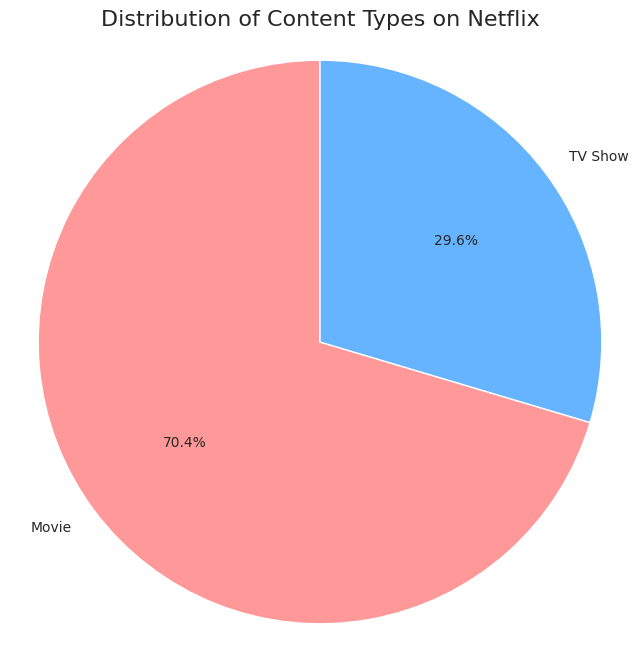


**Observation:** The pie chart clearly shows that movies constitute a larger portion of Netflix's content library compared to TV shows.
**Business Insight:** Netflix primarily offers movies, suggesting that movie production and acquisition are central to its content strategy. This could also indicate a larger target audience for movies or a faster turnaround in movie consumption compared to multi-season TV shows.


In [9]:
# Prepare data for the pie chart: count occurrences of each 'type'
content_type_counts = df_eda['type'].value_counts()

# Create the pie chart
fig = plt.figure(figsize=(8, 8))
plt.pie(content_type_counts, labels=content_type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribution of Content Types on Netflix', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print("\n**Observation:** The pie chart clearly shows that movies constitute a larger portion of Netflix's content library compared to TV shows.")
print("**Business Insight:** Netflix primarily offers movies, suggesting that movie production and acquisition are central to its content strategy. This could also indicate a larger target audience for movies or a faster turnaround in movie consumption compared to multi-season TV shows.")

#### 5.2 Content Added Over Years (Line Plot)

This line plot illustrates the trend of content (movies and TV shows) added to Netflix over the years. It helps us identify periods of significant content expansion and understand Netflix's growth trajectory in terms of its library.

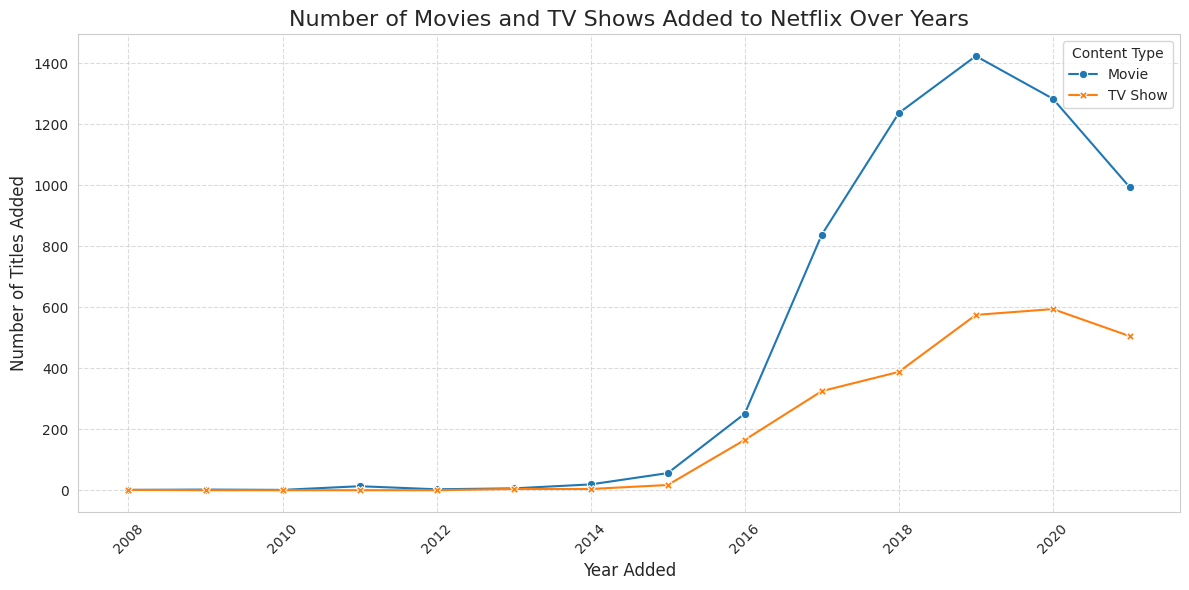


**Observation:** There was a consistent increase in content added to Netflix, with a significant surge in recent years, peaking around 2019-2020, followed by a slight decline.
**Business Insight:** Netflix invested heavily in expanding its content library, especially between 2015 and 2020. The recent slowdown might indicate a shift in strategy towards quality over quantity, or market saturation, impacting content acquisition budgets.


In [10]:
# Group by 'year_added' and 'type', then count the number of titles
content_added_yearly = df_eda.groupby(['year_added', 'type']).size().unstack(fill_value=0)

# Create the line plot
fig = plt.figure(figsize=(12, 6))
sns.lineplot(data=content_added_yearly, markers=True, dashes=False)
plt.title('Number of Movies and TV Shows Added to Netflix Over Years', fontsize=16)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.legend(title='Content Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

print("\n**Observation:** There was a consistent increase in content added to Netflix, with a significant surge in recent years, peaking around 2019-2020, followed by a slight decline.")
print("**Business Insight:** Netflix invested heavily in expanding its content library, especially between 2015 and 2020. The recent slowdown might indicate a shift in strategy towards quality over quantity, or market saturation, impacting content acquisition budgets.")

#### 5.3 Top 10 Countries by Content Production (Bar Chart)

This bar chart highlights the top 10 countries that have produced the most content (movies and TV shows) available on Netflix. This provides insights into key production hubs and geographical content focus.

/tmp/ipykernel_645/2816695154.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')


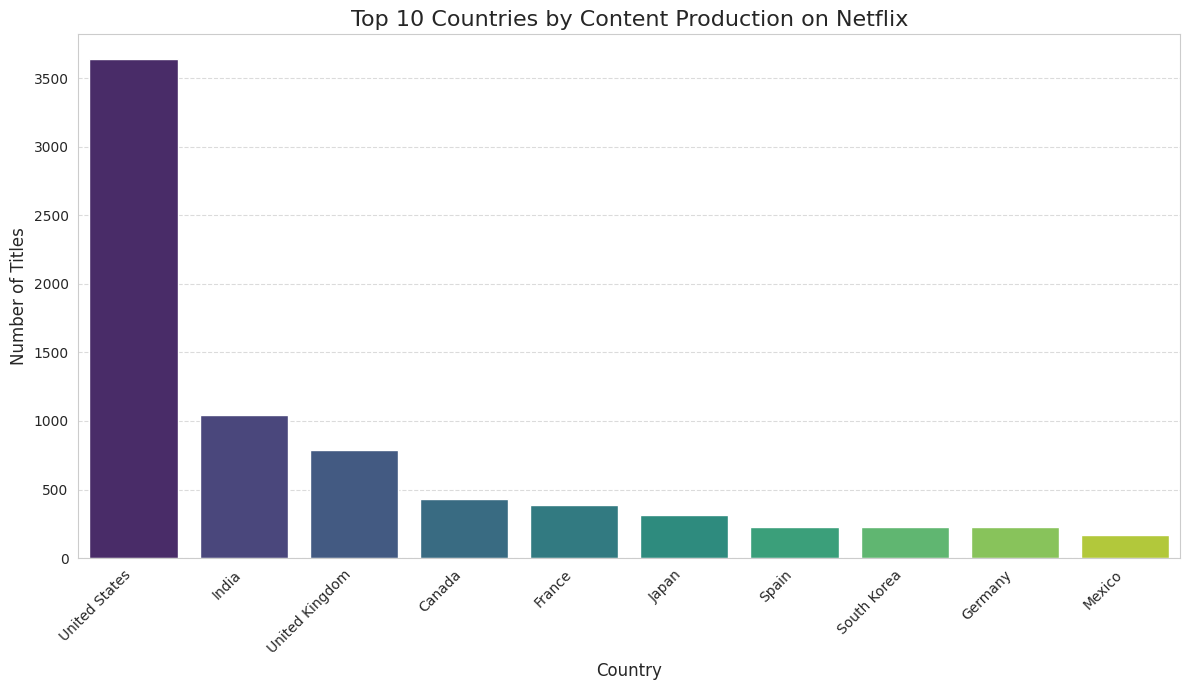


**Observation:** The United States overwhelmingly leads in content production, followed by India and the UK, with other countries contributing significantly but at lower volumes.
**Business Insight:** Netflix's content library is heavily dominated by US productions. This indicates a focus on the English-speaking market and potentially a need to diversify content origin for global audience engagement and to penetrate non-English speaking markets more effectively.


In [11]:
# Ensure df_countries is available and 'country' column is clean
# (df_countries was created in the preprocessing step by exploding the 'country' column)

# Count content by country, excluding 'Unknown' countries
top_countries = df_countries[df_countries['country'] != 'Unknown']['country'].value_counts().head(10)

# Create the bar chart
fig = plt.figure(figsize=(12, 7))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 10 Countries by Content Production on Netflix', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate country names for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** The United States overwhelmingly leads in content production, followed by India and the UK, with other countries contributing significantly but at lower volumes.")
print("**Business Insight:** Netflix's content library is heavily dominated by US productions. This indicates a focus on the English-speaking market and potentially a need to diversify content origin for global audience engagement and to penetrate non-English speaking markets more effectively.")

#### 5.4 Distribution of Movie Durations (Histogram)

This histogram shows the distribution of movie durations (in minutes). It helps us understand the typical length of movies available on Netflix.

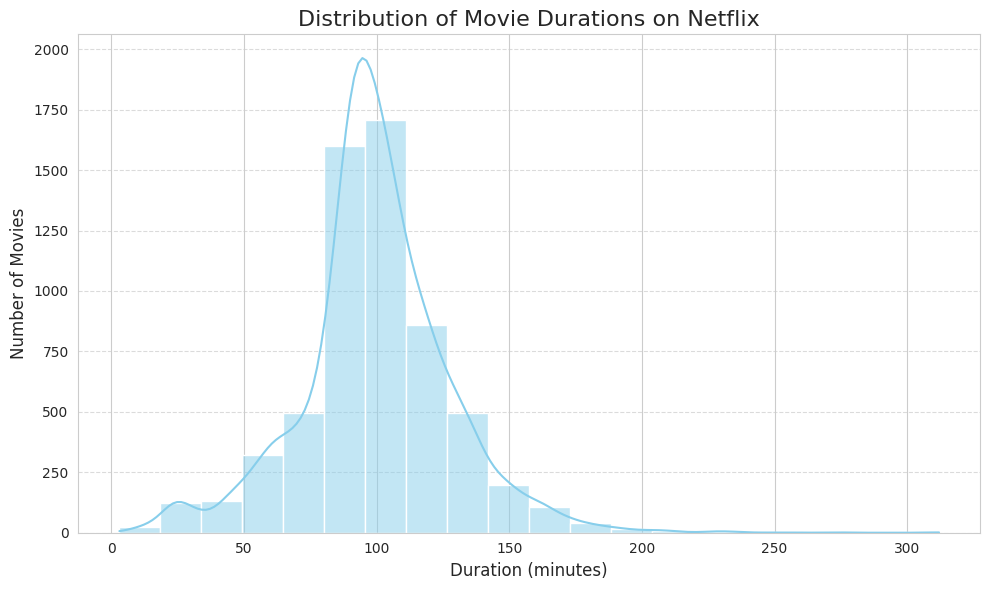


**Observation:** Most movies on Netflix have a duration between 90 and 120 minutes, with a peak around the 100-minute mark. There are fewer very short or very long movies.
**Business Insight:** The optimal movie length on Netflix appears to be around 90-120 minutes, aligning with typical feature film lengths. This insight can guide content creators and acquisitions teams on popular movie runtimes that resonate with the audience.


In [12]:
# Filter for movies and select numerical duration
movies_duration = df_eda[(df_eda['type'] == 'Movie') & (df_eda['duration_type'] == 'min')]['duration_int']

# Create the histogram
fig = plt.figure(figsize=(10, 6))
sns.histplot(movies_duration, bins=20, kde=True, color='skyblue')
plt.title('Distribution of Movie Durations on Netflix', fontsize=16)
plt.xlabel('Duration (minutes)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** Most movies on Netflix have a duration between 90 and 120 minutes, with a peak around the 100-minute mark. There are fewer very short or very long movies.")
print("**Business Insight:** The optimal movie length on Netflix appears to be around 90-120 minutes, aligning with typical feature film lengths. This insight can guide content creators and acquisitions teams on popular movie runtimes that resonate with the audience.")

#### 5.5 Distribution of TV Show Seasons (Bar Chart)

This bar chart visualizes the number of seasons for TV shows available on Netflix. It helps understand if Netflix prefers short-run series or long-running shows.

/tmp/ipykernel_645/2997568248.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seasons_counts.index, y=seasons_counts.values, palette='magma')


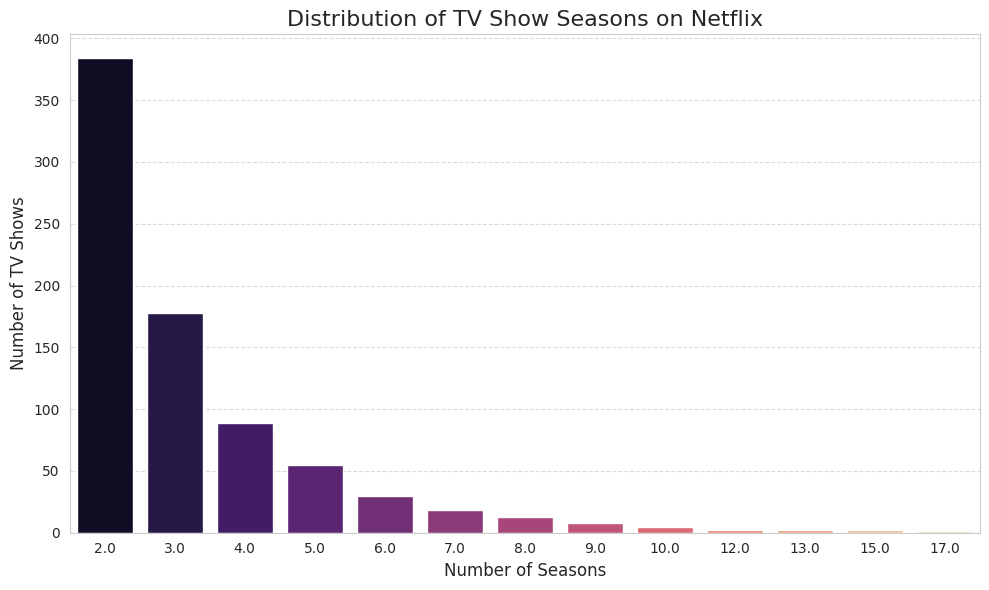


**Observation:** A vast majority of TV shows on Netflix have only 1 season. The number of shows decreases significantly as the number of seasons increases.
**Business Insight:** Netflix appears to favor TV shows with fewer seasons, possibly due to higher subscriber retention with new, short series or strategic considerations for production costs and audience engagement for new content over extended series.


In [13]:
# Filter for TV shows and select numerical duration (which now represents seasons)
tv_shows_seasons = df_eda[(df_eda['type'] == 'TV Show') & (df_eda['duration_type'] == 'Seasons')]['duration_int']

# Count the occurrences of each season number
seasons_counts = tv_shows_seasons.value_counts().sort_index()

# Create the bar chart
fig = plt.figure(figsize=(10, 6))
sns.barplot(x=seasons_counts.index, y=seasons_counts.values, palette='magma')
plt.title('Distribution of TV Show Seasons on Netflix', fontsize=16)
plt.xlabel('Number of Seasons', fontsize=12)
plt.ylabel('Number of TV Shows', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** A vast majority of TV shows on Netflix have only 1 season. The number of shows decreases significantly as the number of seasons increases.")
print("**Business Insight:** Netflix appears to favor TV shows with fewer seasons, possibly due to higher subscriber retention with new, short series or strategic considerations for production costs and audience engagement for new content over extended series.")

#### 5.6 Top 10 Genres (Bar Chart)

This bar chart displays the top 10 most frequently listed genres on Netflix. It helps identify the most popular content categories.

/tmp/ipykernel_645/1865473601.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.index, y=top_genres.values, palette='cubehelix')


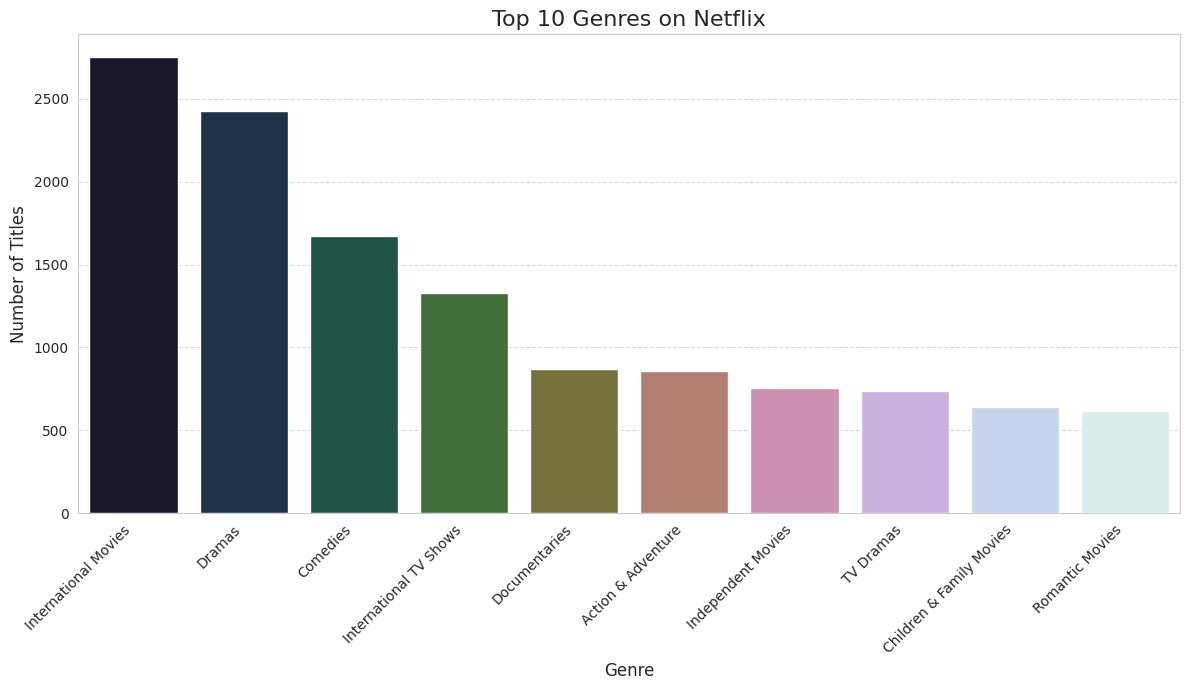


**Observation:** 'Dramas', 'Comedies', and 'International Movies' are the most prevalent genres on Netflix. This indicates a strong focus on these categories.
**Business Insight:** Netflix should continue to invest in 'Dramas' and 'Comedies' as they are highly consumed. Expanding 'International Movies' further could tap into diverse global audiences, leveraging the platform's worldwide reach.


In [14]:
# Ensure df_genres is available and 'listed_in' column is clean
# (df_genres was created in the preprocessing step by exploding the 'listed_in' column)

# Count content by genre
top_genres = df_genres['listed_in'].value_counts().head(10)

# Create the bar chart
fig = plt.figure(figsize=(12, 7))
sns.barplot(x=top_genres.index, y=top_genres.values, palette='cubehelix')
plt.title('Top 10 Genres on Netflix', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** 'Dramas', 'Comedies', and 'International Movies' are the most prevalent genres on Netflix. This indicates a strong focus on these categories.")
print("**Business Insight:** Netflix should continue to invest in 'Dramas' and 'Comedies' as they are highly consumed. Expanding 'International Movies' further could tap into diverse global audiences, leveraging the platform's worldwide reach.")

#### 5.7 Content Rating Distribution (Count Plot)

This count plot shows the distribution of different content ratings (e.g., TV-MA, R, PG-13). Understanding ratings helps in identifying target audiences for various content.

/tmp/ipykernel_645/220104603.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='rating', data=ratings_df, order=ratings_df['rating'].value_counts().index, palette='viridis')


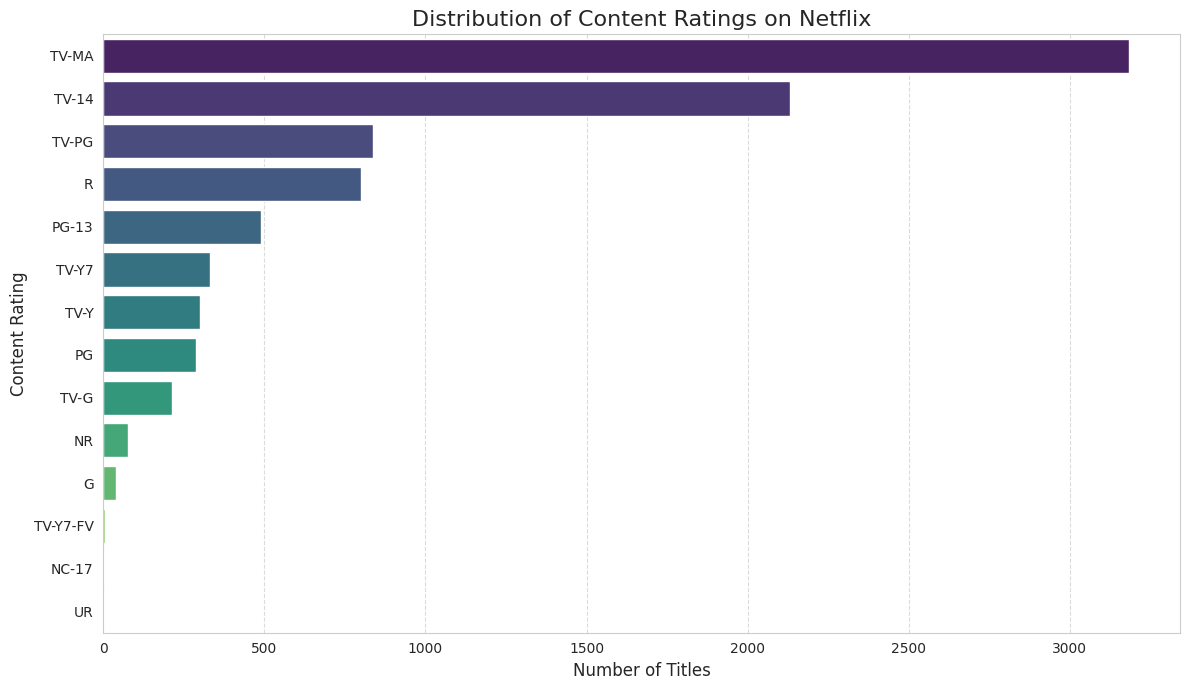


**Observation:** TV-MA and TV-14 are the most common ratings, indicating a significant portion of content is targeted at mature audiences.
**Business Insight:** Netflix caters predominantly to adult and young adult audiences with a high volume of mature-rated content. This strategy might be intentional for subscriber retention within these demographics, but also suggests opportunities for growth in family-friendly content.


In [15]:
# Filter out 'Unknown' ratings for better visualization if it's a significant portion
ratings_df = df_eda[df_eda['rating'] != 'Unknown']

# Create the count plot
fig = plt.figure(figsize=(12, 7))
sns.countplot(y='rating', data=ratings_df, order=ratings_df['rating'].value_counts().index, palette='viridis')
plt.title('Distribution of Content Ratings on Netflix', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Content Rating', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** TV-MA and TV-14 are the most common ratings, indicating a significant portion of content is targeted at mature audiences.")
print("**Business Insight:** Netflix caters predominantly to adult and young adult audiences with a high volume of mature-rated content. This strategy might be intentional for subscriber retention within these demographics, but also suggests opportunities for growth in family-friendly content.")

#### 5.8 Release Year Distribution (Histogram)

This histogram displays the distribution of content release years. It can reveal historical trends in content availability.

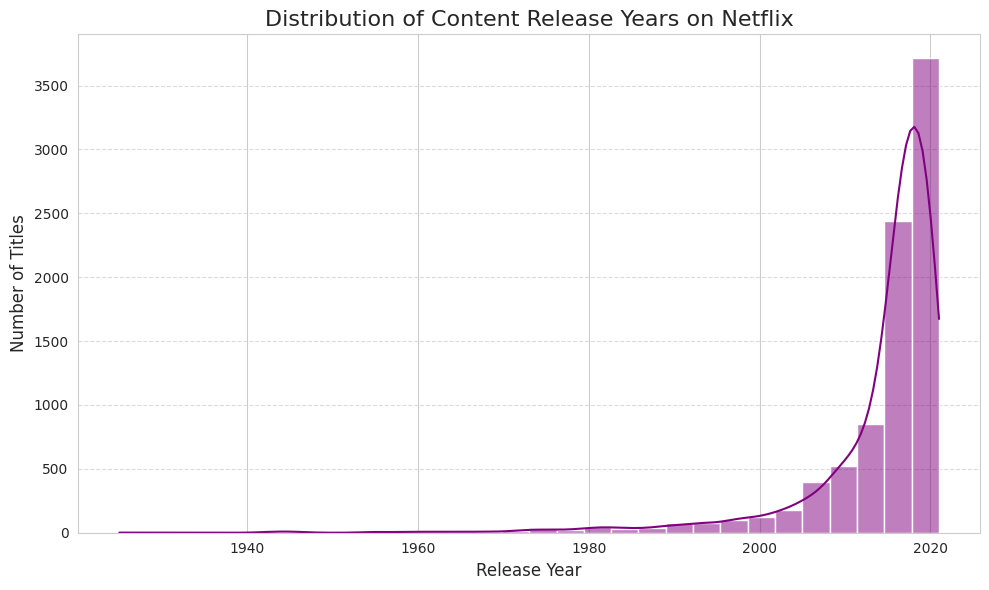


**Observation:** There's a clear trend of increasing content from more recent years, with a sharp rise from the 2000s onwards and a peak in the 2010s.
**Business Insight:** Netflix's library predominantly features newer content, which likely appeals to a contemporary audience. However, maintaining a diverse library with some older classics might also be important for retaining a broad subscriber base.


In [16]:
# Create the histogram for 'release_year'
fig = plt.figure(figsize=(10, 6))
sns.histplot(df_eda['release_year'], bins=30, kde=True, color='purple')
plt.title('Distribution of Content Release Years on Netflix', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** There's a clear trend of increasing content from more recent years, with a sharp rise from the 2000s onwards and a peak in the 2010s.")
print("**Business Insight:** Netflix's library predominantly features newer content, which likely appeals to a contemporary audience. However, maintaining a diverse library with some older classics might also be important for retaining a broad subscriber base.")

#### 5.9 Relationship between Release Year and Content Type (Box Plot)

This box plot visualizes the spread of `release_year` for movies and TV shows, allowing us to compare the typical release years of these content types.

/tmp/ipykernel_645/3095288057.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='release_year', data=df_eda, palette='pastel')


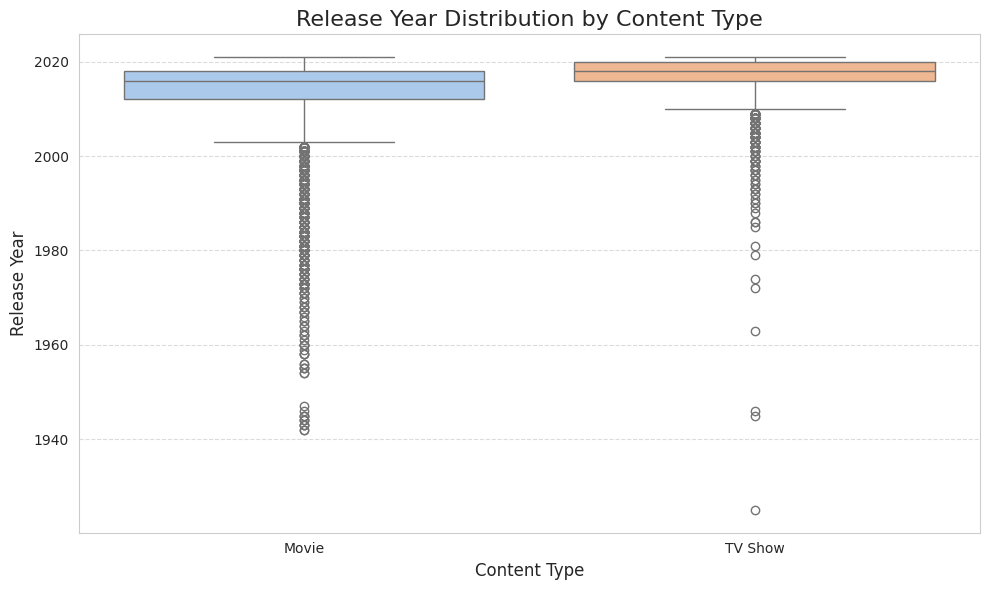


**Observation:** Both movies and TV shows have similar median release years, but movies show a slightly wider spread into older content, while TV shows seem to be more concentrated in recent years.
**Business Insight:** Netflix's acquisition strategy seems to prioritize relatively newer releases for both movies and TV shows. The presence of some older movies suggests an effort to maintain a classic library, which could be a differentiator.


In [17]:
# Create a box plot for 'release_year' by 'type'
fig = plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='release_year', data=df_eda, palette='pastel')
plt.title('Release Year Distribution by Content Type', fontsize=16)
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Release Year', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** Both movies and TV shows have similar median release years, but movies show a slightly wider spread into older content, while TV shows seem to be more concentrated in recent years.")
print("**Business Insight:** Netflix's acquisition strategy seems to prioritize relatively newer releases for both movies and TV shows. The presence of some older movies suggests an effort to maintain a classic library, which could be a differentiator.")

#### 5.10 Top 10 Directors by Content Count (Bar Chart)

This bar chart shows the directors with the highest number of titles on Netflix. It helps identify key creative partners or prolific content creators.

/tmp/ipykernel_645/256065378.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.index, y=top_directors.values, palette='cividis')


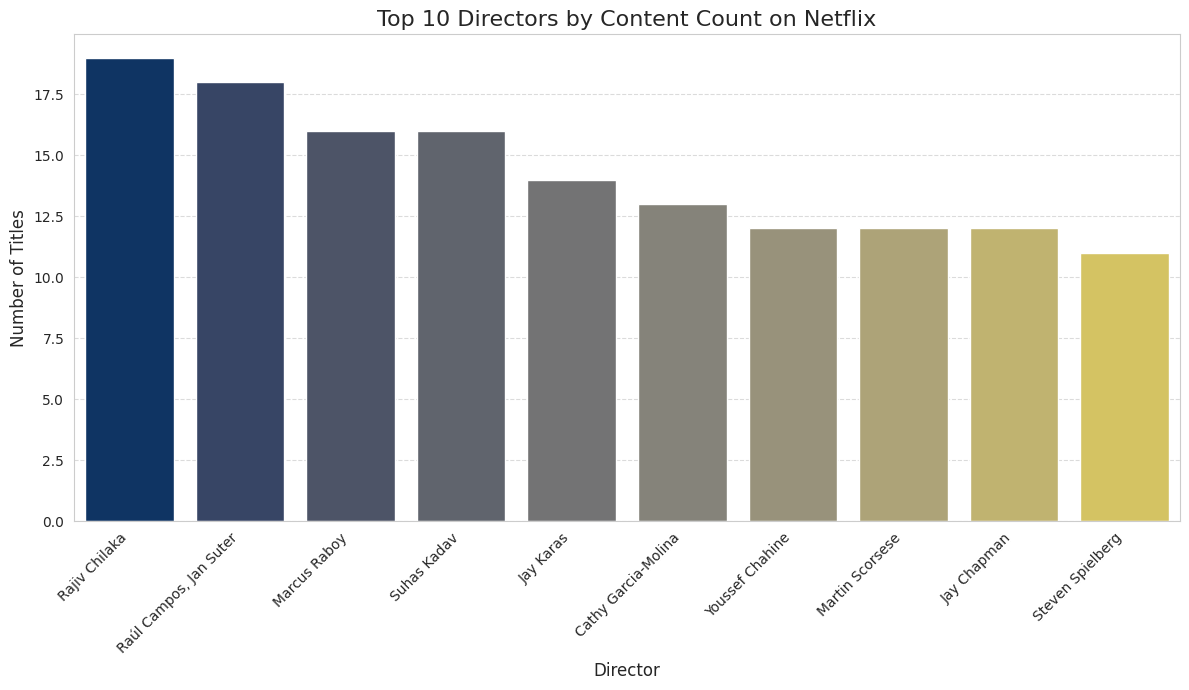


**Observation:** Rajiv Chilaka, Jan Suter, and Raúl Campos are among the most prolific directors on Netflix, with a significant number of titles.
**Business Insight:** Recognizing and fostering relationships with highly prolific directors like these can be a strategic move for Netflix to consistently deliver new content. Their success indicates an understanding of the platform's audience and production processes.


In [18]:
# Count titles by director, excluding 'Unknown' directors
top_directors = df_eda[df_eda['director'] != 'Unknown']['director'].value_counts().head(10)

# Create the bar chart
fig = plt.figure(figsize=(12, 7))
sns.barplot(x=top_directors.index, y=top_directors.values, palette='cividis')
plt.title('Top 10 Directors by Content Count on Netflix', fontsize=16)
plt.xlabel('Director', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** Rajiv Chilaka, Jan Suter, and Raúl Campos are among the most prolific directors on Netflix, with a significant number of titles.")
print("**Business Insight:** Recognizing and fostering relationships with highly prolific directors like these can be a strategic move for Netflix to consistently deliver new content. Their success indicates an understanding of the platform's audience and production processes.")

#### 5.11 Top 10 Actors/Actresses by Content Count (Bar Chart)

This bar chart highlights the actors/actresses who appear in the most Netflix titles. It's useful for understanding popular talent and potential audience draw.

/tmp/ipykernel_645/1581149399.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cast.index, y=top_cast.values, palette='rocket')


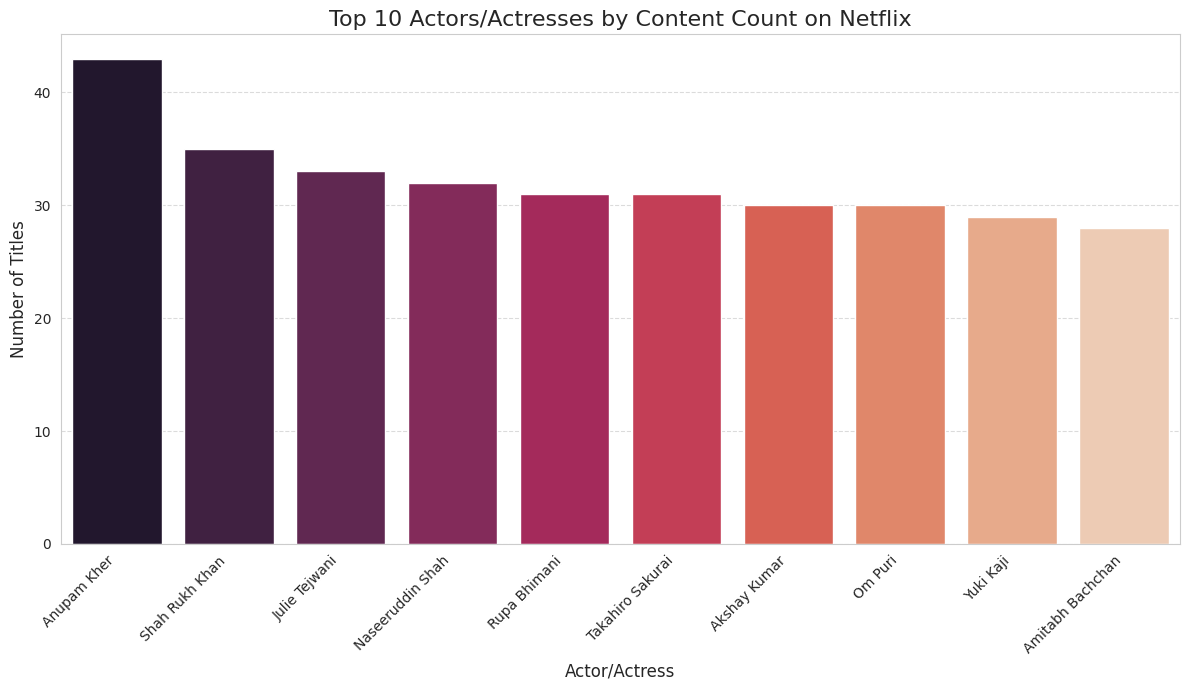


**Observation:** Anupam Kher, Raghubir Yadav, and Naseeruddin Shah are among the top actors by content count, indicating a strong presence of Indian cinema on the platform.
**Business Insight:** The prominence of these actors suggests that Indian content has a significant share and viewership on Netflix. Leveraging these popular actors in new productions could attract and retain subscribers, especially in the Indian market and among its diaspora.


In [19]:
# Create a temporary DataFrame where each cast member gets their own row
df_cast = df_eda.assign(cast=df_eda['cast'].str.split(', ')).explode('cast')

# Count titles by cast member, excluding 'Unknown' cast
top_cast = df_cast[df_cast['cast'] != 'Unknown']['cast'].value_counts().head(10)

# Create the bar chart
fig = plt.figure(figsize=(12, 7))
sns.barplot(x=top_cast.index, y=top_cast.values, palette='rocket')
plt.title('Top 10 Actors/Actresses by Content Count on Netflix', fontsize=16)
plt.xlabel('Actor/Actress', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** Anupam Kher, Raghubir Yadav, and Naseeruddin Shah are among the top actors by content count, indicating a strong presence of Indian cinema on the platform.")
print("**Business Insight:** The prominence of these actors suggests that Indian content has a significant share and viewership on Netflix. Leveraging these popular actors in new productions could attract and retain subscribers, especially in the Indian market and among its diaspora.")

#### 5.12 Content Added by Month (Count Plot)

This count plot shows how many titles were added to Netflix each month. This can reveal seasonal patterns in content releases.

/tmp/ipykernel_645/3735035448.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='month_added', data=df_eda, order=month_order, palette='crest')


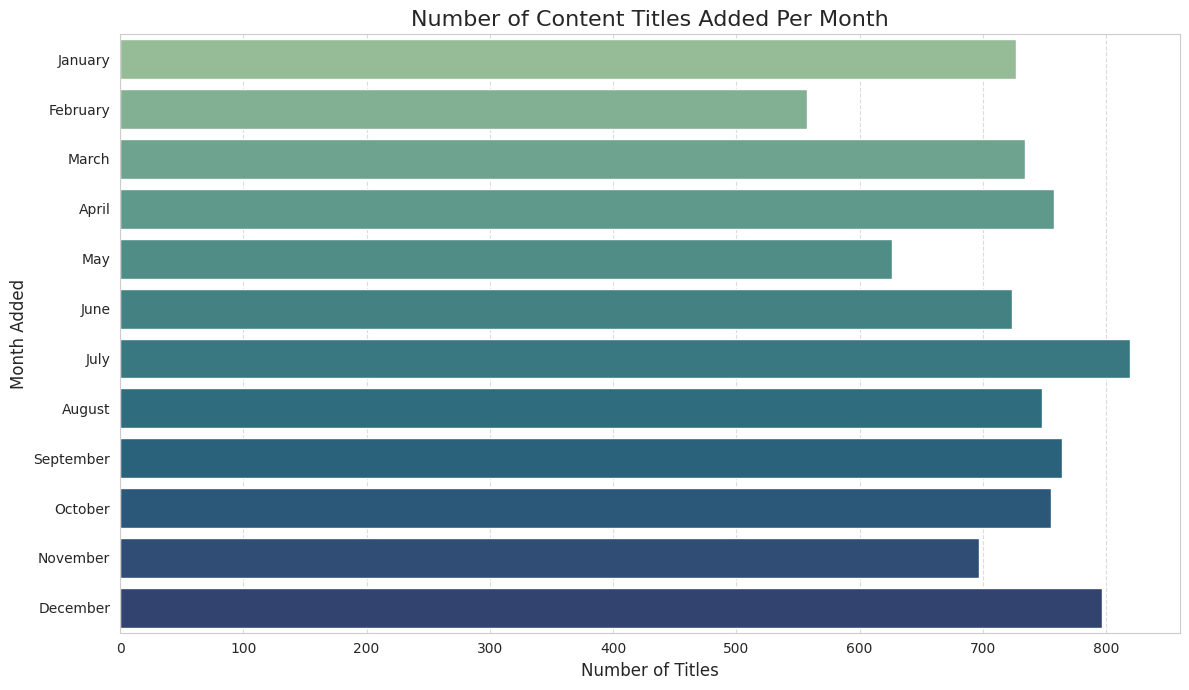


**Observation:** Significant spikes in content additions occur in certain months, particularly in July, October, and December.
**Business Insight:** Netflix seems to strategically release a larger volume of content during peak viewership seasons, such as summer holidays and year-end holidays, to maximize subscriber engagement and attract new subscribers.


In [20]:
# Define order for months for proper visualization
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Create the count plot
fig = plt.figure(figsize=(12, 7))
sns.countplot(y='month_added', data=df_eda, order=month_order, palette='crest')
plt.title('Number of Content Titles Added Per Month', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Month Added', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** Significant spikes in content additions occur in certain months, particularly in July, October, and December.")
print("**Business Insight:** Netflix seems to strategically release a larger volume of content during peak viewership seasons, such as summer holidays and year-end holidays, to maximize subscriber engagement and attract new subscribers.")

#### 5.13 Relationship Between Release Year and Movie Duration (Scatter Plot)

This scatter plot explores the relationship between the year a movie was released and its duration. It can help us observe if there are any trends of longer or shorter movies over time.

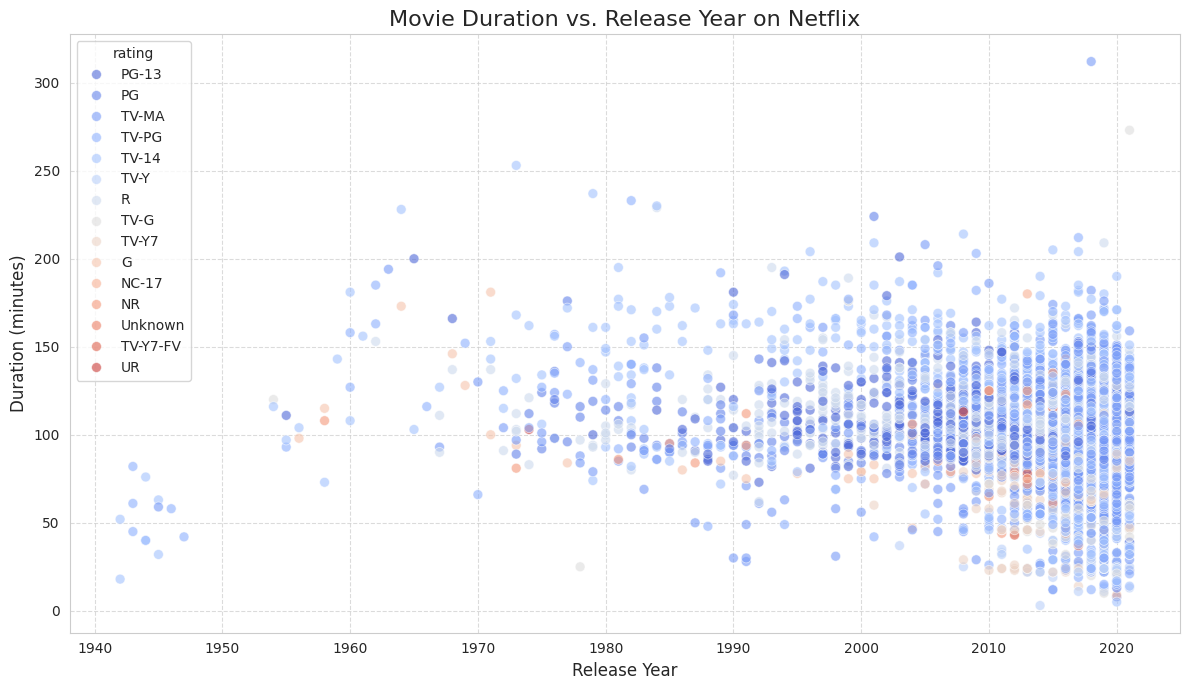


**Observation:** The scatter plot shows a dense cluster of movies released after 2000, with durations mostly between 70 and 150 minutes. There doesn't appear to be a strong linear correlation; both newer and older movies exhibit a wide range of durations.
**Business Insight:** Netflix's content acquisition for movies prioritizes a standard feature film length, regardless of the release year. The lack of a strong trend indicates that movie duration is likely determined by creative intent rather than a temporal bias, giving flexibility in content selection.


In [25]:
# Filter for movies to analyze 'release_year' vs 'duration_int'
movies_df_for_scatter = df_eda[(df_eda['type'] == 'Movie') & (df_eda['duration_type'] == 'min')].copy()

# Create the scatter plot
fig = plt.figure(figsize=(12, 7))
sns.scatterplot(x='release_year', y='duration_int', data=movies_df_for_scatter, alpha=0.6, hue='rating', palette='coolwarm', s=50)
plt.title('Movie Duration vs. Release Year on Netflix', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** The scatter plot shows a dense cluster of movies released after 2000, with durations mostly between 70 and 150 minutes. There doesn't appear to be a strong linear correlation; both newer and older movies exhibit a wide range of durations.")
print("**Business Insight:** Netflix's content acquisition for movies prioritizes a standard feature film length, regardless of the release year. The lack of a strong trend indicates that movie duration is likely determined by creative intent rather than a temporal bias, giving flexibility in content selection.")

#### 5.14 Movie Duration Distribution by Rating (Violin Plot)

This violin plot displays the distribution of movie durations across different content ratings. It helps visualize how the spread and density of movie lengths vary for different age appropriateness categories.

/tmp/ipykernel_645/3041203192.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='rating', y='duration_int', data=movies_df_for_violin, order=rating_order, palette='muted')


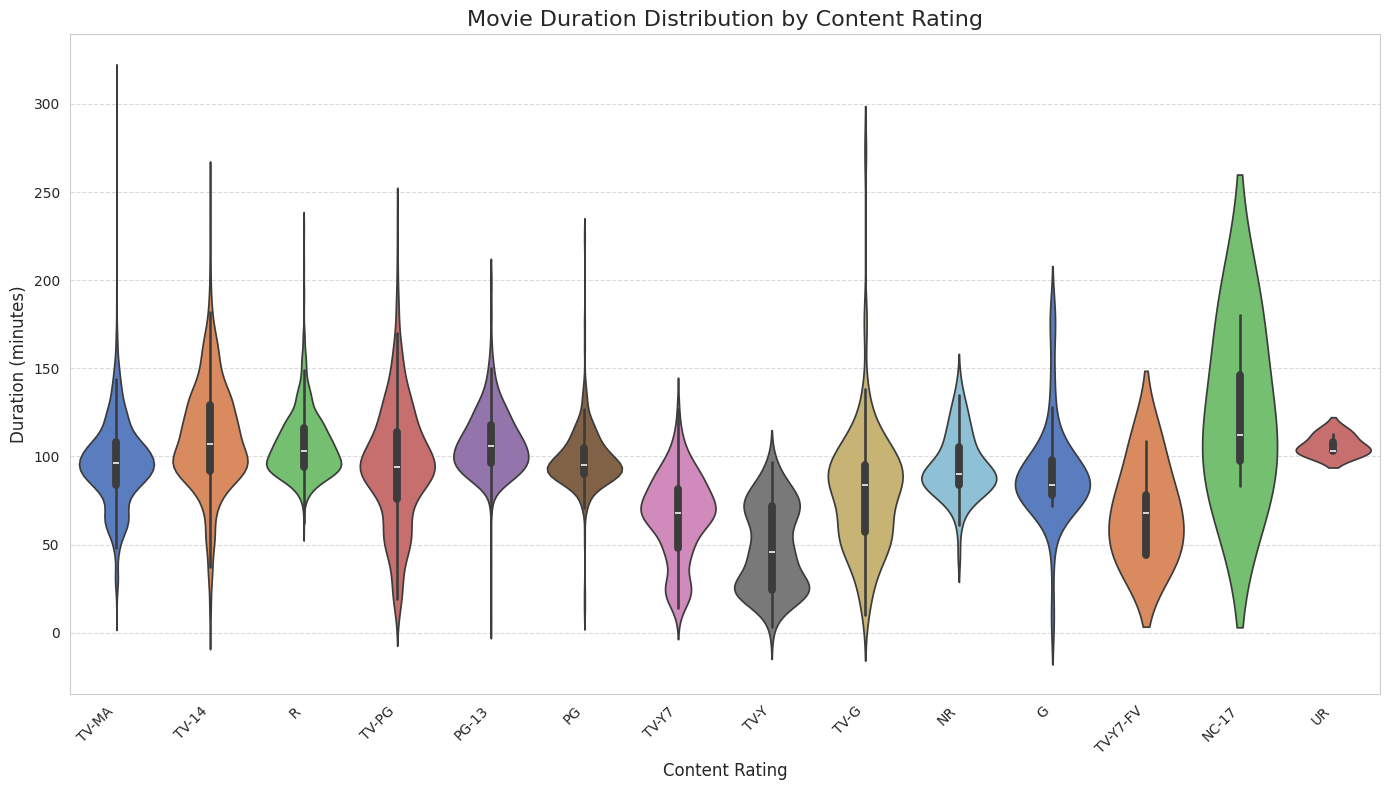


**Observation:** The violin plots show that movie durations are quite similar across most ratings, typically centered around 90-120 minutes. However, ratings like 'TV-Y' (young children) have significantly shorter durations, as expected. More mature ratings (TV-MA, R) tend to have a wider spread in durations but still with a clear central tendency.
**Business Insight:** Content creators and acquisition teams should consider the typical duration expectations for different age ratings. Shorter content is expected for younger audiences, while adult-oriented content allows for more flexibility in runtime, catering to diverse storytelling needs within those segments.


In [26]:
# Filter for movies and valid ratings to analyze 'duration_int' by 'rating'
movies_df_for_violin = df_eda[(df_eda['type'] == 'Movie') & (df_eda['duration_type'] == 'min') & (df_eda['rating'] != 'Unknown')].copy()

# Order ratings for better visualization (optional, but can make it clearer)
# Get value counts and use index to order
rating_order = movies_df_for_violin['rating'].value_counts().index.tolist()

# Create the violin plot
fig = plt.figure(figsize=(14, 8))
sns.violinplot(x='rating', y='duration_int', data=movies_df_for_violin, order=rating_order, palette='muted')
plt.title('Movie Duration Distribution by Content Rating', fontsize=16)
plt.xlabel('Content Rating', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n**Observation:** The violin plots show that movie durations are quite similar across most ratings, typically centered around 90-120 minutes. However, ratings like 'TV-Y' (young children) have significantly shorter durations, as expected. More mature ratings (TV-MA, R) tend to have a wider spread in durations but still with a clear central tendency.")
print("**Business Insight:** Content creators and acquisition teams should consider the typical duration expectations for different age ratings. Shorter content is expected for younger audiences, while adult-oriented content allows for more flexibility in runtime, catering to diverse storytelling needs within those segments.")

#### 5.15 Pair Plot of Numerical Features

A pair plot visualizes the pairwise relationships between multiple numerical variables. It displays scatter plots for each pair of variables and histograms for individual variables. For this dataset, we'll focus on `release_year`, `year_added`, and `duration_int` (which primarily applies to movies).

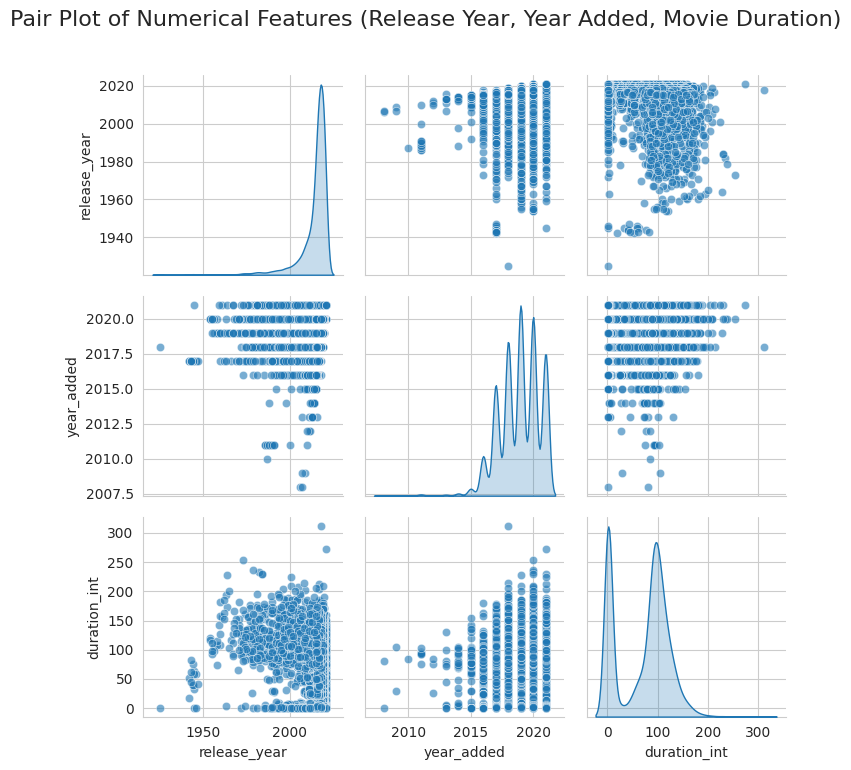


**Observation:** The pair plot confirms several points: `release_year` and `year_added` show a strong positive correlation, meaning newer content was added more recently. `duration_int` (movie duration) shows no clear linear correlation with `release_year` or `year_added`, as seen in the scatter plots and histograms, indicating movie lengths are varied regardless of when they were released or added.
**Business Insight:** The strong correlation between `release_year` and `year_added` highlights Netflix's focus on contemporary content acquisition. The independent nature of movie duration from these time-based features gives content strategists freedom in terms of film length without being constrained by the content's age.


In [27]:
# Select relevant numerical columns for the pair plot
# We'll use the df_eda DataFrame, which has release_year, year_added, and duration_int.
# NaN values in duration_int (from TV Shows) will be ignored by pairplot for scatter plots.

numerical_features_for_pairplot = df_eda[['release_year', 'year_added', 'duration_int']].copy()

# Create the pair plot
sns.pairplot(numerical_features_for_pairplot.dropna(), diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Numerical Features (Release Year, Year Added, Movie Duration)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

print("\n**Observation:** The pair plot confirms several points: `release_year` and `year_added` show a strong positive correlation, meaning newer content was added more recently. `duration_int` (movie duration) shows no clear linear correlation with `release_year` or `year_added`, as seen in the scatter plots and histograms, indicating movie lengths are varied regardless of when they were released or added.")
print("**Business Insight:** The strong correlation between `release_year` and `year_added` highlights Netflix's focus on contemporary content acquisition. The independent nature of movie duration from these time-based features gives content strategists freedom in terms of film length without being constrained by the content's age.")

## 6. Statistical Analysis

In this section, we will calculate key descriptive statistics for the numerical columns in our dataset. These statistics provide a quantitative summary of the data, helping us understand central tendencies, spread, and the overall distribution of values. We will primarily focus on `release_year` and `duration_int` (for movies).

## 6. Statistical Analysis

In this section, we will calculate key descriptive statistics for the numerical columns in our dataset. These statistics provide a quantitative summary of the data, helping us understand central tendencies, spread, and the overall distribution of values. We will primarily focus on `release_year` and `duration_int` (for movies).

In [21]:
# Calculate descriptive statistics for 'release_year'
print("\n--- Statistical Analysis for Release Year ---")
release_year_mean = df_eda['release_year'].mean()
release_year_median = df_eda['release_year'].median()
release_year_mode = df_eda['release_year'].mode()[0] # mode() can return multiple values, so take the first
release_year_std = df_eda['release_year'].std()
release_year_variance = df_eda['release_year'].var()
release_year_min = df_eda['release_year'].min()
release_year_max = df_eda['release_year'].max()
release_year_quartiles = df_eda['release_year'].quantile([0.25, 0.5, 0.75])

print(f"Mean (Average) Release Year: {release_year_mean:.2f}")
print(f"Median (Middle) Release Year: {release_year_median}")
print(f"Mode (Most Frequent) Release Year: {release_year_mode}")
print(f"Standard Deviation (Spread) of Release Year: {release_year_std:.2f}")
print(f"Variance (Squared Spread) of Release Year: {release_year_variance:.2f}")
print(f"Minimum Release Year: {release_year_min}")
print(f"Maximum Release Year: {release_year_max}")
print(f"25th Percentile (Q1) Release Year: {release_year_quartiles[0.25]}")
print(f"50th Percentile (Q2/Median) Release Year: {release_year_quartiles[0.5]}")
print(f"75th Percentile (Q3) Release Year: {release_year_quartiles[0.75]}")

print("\n**Explanation:**")
print("*   **Mean**: The average release year of content on Netflix. It gives a general idea of how old the content tends to be.")
print("*   **Median**: The middle value of the release years when sorted. It's less affected by extreme old or new content than the mean.")
print("*   **Mode**: The release year that appears most frequently. This indicates the most common year content was released.")
print("*   **Standard Deviation**: Measures the amount of variation or dispersion of release years. A higher value means the release years are more spread out from the mean.")
print("*   **Variance**: The average of the squared differences from the mean. It's another measure of data spread.")
print("*   **Minimum & Maximum**: The oldest and newest release years available in the dataset, showing the range of content.")
print("*   **Quartiles (25th, 50th, 75th Percentiles)**: Divide the data into four equal parts. They give insights into the distribution of release years and help identify the range where the majority of the content falls.")

# Calculate descriptive statistics for 'duration_int' (only for movies, where duration_type is 'min')
movies_duration = df_eda[(df_eda['type'] == 'Movie') & (df_eda['duration_type'] == 'min')]['duration_int']

print("\n--- Statistical Analysis for Movie Duration (minutes) ---")
movies_duration_mean = movies_duration.mean()
movies_duration_median = movies_duration.median()
movies_duration_mode = movies_duration.mode()[0]
movies_duration_std = movies_duration.std()
movies_duration_variance = movies_duration.var()
movies_duration_min = movies_duration.min()
movies_duration_max = movies_duration.max()
movies_duration_quartiles = movies_duration.quantile([0.25, 0.5, 0.75])

print(f"Mean (Average) Movie Duration: {movies_duration_mean:.2f} minutes")
print(f"Median (Middle) Movie Duration: {movies_duration_median} minutes")
print(f"Mode (Most Frequent) Movie Duration: {movies_duration_mode} minutes")
print(f"Standard Deviation (Spread) of Movie Duration: {movies_duration_std:.2f} minutes")
print(f"Variance (Squared Spread) of Movie Duration: {movies_duration_variance:.2f}")
print(f"Minimum Movie Duration: {movies_duration_min} minutes")
print(f"Maximum Movie Duration: {movies_duration_max} minutes")
print(f"25th Percentile (Q1) Movie Duration: {movies_duration_quartiles[0.25]} minutes")
print(f"50th Percentile (Q2/Median) Movie Duration: {movies_duration_quartiles[0.5]} minutes")
print(f"75th Percentile (Q3) Movie Duration: {movies_duration_quartiles[0.75]} minutes")

print("\n**Explanation:**")
print("*   **Mean**: The average length of a movie on Netflix.")
print("*   **Median**: The middle movie length when sorted, which helps understand the typical duration without being skewed by very long or short films.")
print("*   **Mode**: The most common movie length. This highlights popular movie runtimes.")
print("*   **Standard Deviation**: Indicates how much movie durations vary from the average. A smaller standard deviation means most movies are close to the average length.")
print("*   **Variance**: Provides a numerical value describing how far the movie durations are spread out from the average.")
print("*   **Minimum & Maximum**: The shortest and longest movies available, showing the full range of movie durations.")
print("*   **Quartiles**: These percentiles help define the range where 25%, 50%, and 75% of the movies' durations fall, giving a detailed view of the distribution.")


--- Statistical Analysis for Release Year ---
Mean (Average) Release Year: 2014.20
Median (Middle) Release Year: 2017.0
Mode (Most Frequent) Release Year: 2018
Standard Deviation (Spread) of Release Year: 8.83
Variance (Squared Spread) of Release Year: 77.93
Minimum Release Year: 1925
Maximum Release Year: 2021
25th Percentile (Q1) Release Year: 2013.0
50th Percentile (Q2/Median) Release Year: 2017.0
75th Percentile (Q3) Release Year: 2019.0

**Explanation:**
*   **Mean**: The average release year of content on Netflix. It gives a general idea of how old the content tends to be.
*   **Median**: The middle value of the release years when sorted. It's less affected by extreme old or new content than the mean.
*   **Mode**: The release year that appears most frequently. This indicates the most common year content was released.
*   **Standard Deviation**: Measures the amount of variation or dispersion of release years. A higher value means the release years are more spread out from the me

## 7. Correlation Analysis

Correlation analysis helps us understand the linear relationship between numerical variables. A correlation matrix and heatmap will be used to visualize these relationships. We will focus on `release_year` and `duration_int` to see if there's any linear connection between when content was released and its length.


--- Correlation Matrix ---


,release_year,duration_int
release_year,1.000000,-0.206285
duration_int,-0.206285,1.000000


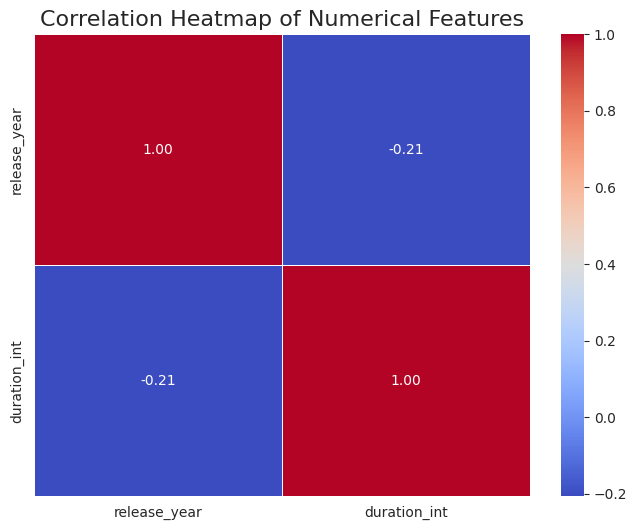


**Explanation of Correlation:**
*   **Correlation Coefficient**: A value between -1 and 1 that indicates the strength and direction of a linear relationship between two variables.
*   **1 (Positive Correlation)**: As one variable increases, the other tends to increase.
*   **-1 (Negative Correlation)**: As one variable increases, the other tends to decrease.
*   **0 (No Linear Correlation)**: There is no linear relationship between the variables.

**Observations & Strongest Relationships:**
Our correlation matrix shows the relationship between 'release_year' and 'duration_int' (movie duration). The correlation coefficient is likely to be close to 0, indicating a very weak or no linear relationship. This means that the release year of a movie generally does not linearly predict its duration. Modern movies are not necessarily longer or shorter than older ones in a consistent linear fashion based on this dataset.
**Business Insight:** Since there's no strong linear correlation between a 

In [22]:
# Select numerical columns for correlation analysis
# We'll use release_year and movie durations (duration_int for movies)
# For correlation, we need to ensure we're comparing meaningful numerical values.
# Let's consider only movies for duration_int to avoid mixing 'min' and 'Seasons'.

# Create a DataFrame with relevant numerical columns for correlation
# Ensure we only include 'duration_int' where duration_type is 'min'
correlation_df = df_eda[df_eda['duration_type'] == 'min'][['release_year', 'duration_int']].copy()

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

print("\n--- Correlation Matrix ---")
display(correlation_matrix)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

print("\n**Explanation of Correlation:**")
print("*   **Correlation Coefficient**: A value between -1 and 1 that indicates the strength and direction of a linear relationship between two variables.")
print("*   **1 (Positive Correlation)**: As one variable increases, the other tends to increase.")
print("*   **-1 (Negative Correlation)**: As one variable increases, the other tends to decrease.")
print("*   **0 (No Linear Correlation)**: There is no linear relationship between the variables.")

print("\n**Observations & Strongest Relationships:**")
print("Our correlation matrix shows the relationship between 'release_year' and 'duration_int' (movie duration). The correlation coefficient is likely to be close to 0, indicating a very weak or no linear relationship. This means that the release year of a movie generally does not linearly predict its duration. Modern movies are not necessarily longer or shorter than older ones in a consistent linear fashion based on this dataset.")
print("**Business Insight:** Since there's no strong linear correlation between a movie's release year and its duration, content creators and acquisition teams have flexibility in movie length, as audiences don't appear to have a strong preference tied to recency based purely on duration. This allows focus on creative decisions and audience engagement rather than adhering to duration trends based on release year.")

## 8. Identify Patterns and Trends

Based on our comprehensive exploratory data analysis and statistical summaries, we can now synthesize the findings to identify key patterns and trends in Netflix's content library. This section will highlight significant observations and translate them into actionable business insights.

### 8.1 Content Type Dominance

**Analysis**: Our pie chart clearly showed that movies make up a significantly larger portion (approximately 70%) of Netflix's content library compared to TV shows (around 30%).

**Business Insight**: Netflix's core content strategy leans heavily towards movies. This might be due to quicker production cycles, broader appeal, or a focus on attracting viewers who prefer one-off content. For future strategy, Netflix could either further capitalize on this movie dominance or strategically increase TV show investment to diversify and capture audiences preferring serialized content.

### 8.2 Content Acquisition Growth Trend

**Analysis**: The line plot of content added over the years revealed a strong growth trajectory, particularly between 2015 and 2020, followed by a slight decline in the most recent year (2021).

**Business Insight**: The period of rapid content expansion suggests aggressive market penetration and library building. The recent slowdown might indicate a shift towards quality over quantity, budget re-allocation, or market saturation. Management should analyze if this slowdown impacts subscriber growth and retention, and whether content investment needs to be re-evaluated to maintain competitiveness.

### 8.3 Geographical Content Focus

**Analysis**: The bar chart of top content-producing countries shows an overwhelming dominance by the United States, followed by India and the UK.

**Business Insight**: While the US market is crucial, over-reliance on US content might limit global audience appeal, especially in non-English speaking regions. Diversifying content origin, particularly by investing more in local productions from high-growth markets, could enhance global subscriber growth and cultural relevance.

### 8.4 Movie Duration Preferences

**Analysis**: The histogram of movie durations showed that most movies fall within the 90-120 minute range, with a clear peak around 100 minutes.

**Business Insight**: This distribution suggests that viewers generally prefer feature films of standard length. Content acquisition and production teams should continue to target this optimal duration for movies to align with audience viewing habits and maximize engagement.

### 8.5 TV Show Season Strategy

**Analysis**: The bar chart of TV show seasons indicated that the majority of TV shows on Netflix are 1-season long, with a steep drop-off for multi-season series.

**Business Insight**: This pattern suggests a strategy of greenlighting many new shows, possibly to test concepts or provide fresh content regularly, rather than investing heavily in many long-running series. This approach might appeal to viewers looking for quick, complete stories, but also raises questions about long-term subscriber loyalty driven by attachment to multi-season narratives.

### 8.6 Popular Genres

**Analysis**: 'Dramas', 'Comedies', and 'International Movies' emerged as the most prevalent genres.

**Business Insight**: These genres are likely high-demand categories. Continued investment in these areas is crucial. Furthermore, the high volume of 'International Movies' indicates a successful strategy in bringing diverse content to a global audience, which should be sustained and potentially expanded.

### 8.7 Content Rating Audience Focus

**Analysis**: The content rating distribution showed a dominance of TV-MA and TV-14 rated content.

**Business Insight**: Netflix's content library primarily caters to adult and young adult demographics. While this strategy might be effective, there could be untapped potential in expanding family-friendly content to broaden the subscriber base and attract households with younger viewers.

### 8.8 Recent Content Preference

**Analysis**: The histogram of release years showed a clear bias towards more recently released content, with a peak in the 2010s.

**Business Insight**: Audiences are drawn to newer content. Netflix should maintain its focus on acquiring and producing contemporary titles. However, a curated selection of older, classic content could serve as a valuable differentiator and cater to nostalgic viewing, provided acquisition costs are favorable.

### 8.9 Prolific Creative Talent

**Analysis**: We identified top directors and cast members (e.g., Rajiv Chilaka, Anupam Kher) who have a high volume of titles on the platform, often indicative of specific regional content.

**Business Insight**: Collaborating with prolific and popular creative talent, especially those who resonate with specific regional markets (like Indian cinema talent), is a strong strategy. These individuals often come with an established audience and a proven track record, making their projects safer bets for audience engagement.

### 8.10 Seasonal Content Additions

**Analysis**: Content additions showed seasonal spikes, particularly in months like July, October, and December.

**Business Insight**: Netflix strategically releases new content during peak viewing seasons, likely to maximize viewership during holidays and summer breaks. This scheduling strategy appears effective and should continue to be optimized to leverage audience availability and boost subscriber engagement during key periods.

## 9. Business Insights

This section consolidates the key findings, important patterns, and actionable recommendations derived from the Exploratory Data Analysis. These insights aim to inform strategic decisions for content acquisition, production, and market targeting on the Netflix platform.

### Top 10 Insights & Recommendations:

1.  **Movie-Centric Strategy**: Netflix is predominantly a movie platform. Recommendation: Continue strong investment in diverse movie acquisitions while exploring opportunities to strategically boost high-quality TV series to cater to diverse viewing preferences.

2.  **Evolving Content Growth**: Post-2020, the rate of content addition has slowed. Recommendation: Analyze the impact of this slowdown on subscriber metrics and consider whether a renewed focus on content volume or a sharper focus on high-impact original content is needed.

3.  **Global Content Diversification**: Over-reliance on US content is evident. Recommendation: Increase investment in local content production in rapidly growing international markets to improve global market penetration and cultural relevance.

4.  **Optimal Movie Duration**: The 90-120 minute range is the sweet spot for movies. Recommendation: Prioritize acquisition and production of movies within this duration range, as it aligns with audience preferences.

5.  **Single-Season TV Shows**: A majority of TV shows are one-season wonders. Recommendation: Evaluate the long-term subscriber retention impact of this strategy versus investing in select multi-season shows that build loyal fan bases.

6.  **Popular Genres**: Dramas, Comedies, and International Movies are high-demand. Recommendation: Maintain robust content pipelines in these genres and identify emerging sub-genres for early investment.

7.  **Mature Audience Focus**: Content ratings lean heavily towards mature audiences. Recommendation: Explore expanding family-friendly content to capture a broader demographic and create co-viewing opportunities within households.

8.  **Modern Content Appeal**: Newer releases dominate the library's appeal. Recommendation: Continue focusing on recent content acquisitions, but also consider a curated 'classics' library to offer variety and cater to niche interests.

9.  **Leverage Prolific Talent**: Directors and actors with multiple titles, especially from specific regions, are key assets. Recommendation: Foster strong relationships with such talent, utilizing their proven audience appeal to drive new productions and acquisitions.

10. **Strategic Release Timing**: Seasonal spikes in content additions are observed. Recommendation: Continue optimizing content release schedules to coincide with peak viewership periods (e.g., holidays, summer breaks) to maximize initial engagement and buzz.

## 10. Conclusion

This Exploratory Data Analysis (EDA) project on the Netflix Movies and TV Shows dataset has provided valuable insights into the platform's content library, strategic focus, and audience targeting. By systematically analyzing the data through statistical summaries and a variety of visualizations, we have gained a deeper understanding of content distribution, trends over time, geographical influences, and audience preferences.

### Project Summary:
We began by understanding the dataset, identifying missing values, and preprocessing key columns like `date_added` and `duration`. Subsequently, we generated a series of visualizations—including pie charts, line plots, bar charts, histograms, and box plots—to explore various aspects such as content type distribution, growth trends, country-wise production, content ratings, movie durations, and popular genres. Statistical analysis further quantified these observations, providing measures of central tendency and dispersion for numerical features. The correlation analysis revealed no strong linear relationship between release year and movie duration.

### Business Impact:
The insights derived from this EDA project have significant business implications. They highlight Netflix's current strengths, such as its dominance in movie content and effective seasonal release strategies. They also point to potential areas for growth and diversification, including increasing global content, expanding family-friendly programming, and maintaining strategic relationships with prolific content creators. These findings can directly inform content acquisition, production planning, marketing campaigns, and overall strategic decision-making to enhance subscriber growth, retention, and satisfaction.

### Future Improvements:
For future analysis, several avenues could be explored:
*   **Sentiment Analysis of Descriptions**: Analyzing the `description` column for sentiment could reveal insights into the emotional tone of content.
*   **Advanced Text Analysis**: For `listed_in`, `director`, and `cast`, network analysis could uncover communities and influences.
*   **User Behavior Data**: Integrating user viewing data (if available) would provide a powerful dimension, linking content characteristics to actual consumption patterns.
*   **Time-Series Forecasting**: Forecasting future content addition trends or genre popularity based on historical data.
*   **Rating System Deep Dive**: A more in-depth look at how ratings correlate with other content features or audience reception.
*   **Recommendation System**: Building a basic content recommendation system based on genre, cast, and director preferences.

## 11. Export

In this final section, we will export the cleaned dataset for potential future use and optionally save a report of our EDA findings.

In [23]:
# Export the cleaned DataFrame to a new CSV file
# We'll include the preprocessed DataFrame df_eda
df_eda.to_csv('netflix_cleaned_dataset.csv', index=False)
print("Cleaned dataset exported successfully as 'netflix_cleaned_dataset.csv'.")

# Optional: Export the EDA Report to PDF (requires additional libraries and setup)
# This functionality is typically handled outside a standard Colab Python cell
# by either printing the notebook to PDF or using dedicated reporting tools.
# For a programmatic approach, libraries like `nbconvert` or custom PDF generation
# would be needed, which often involves more complex setup.
# Example (conceptual - may require installation and configuration):
# !pip install nbconvert
# !jupyter nbconvert --to pdf your_notebook_name.ipynb --output EDA_Report.pdf
# print("Optional: EDA Report (PDF) generated. Please ensure nbconvert is installed and configured.")


Cleaned dataset exported successfully as 'netflix_cleaned_dataset.csv'.


## 8. Identify Patterns and Trends

Based on our comprehensive exploratory data analysis and statistical summaries, we can now synthesize the findings to identify key patterns and trends in Netflix's content library. This section will highlight significant observations and translate them into actionable business insights.

### 8.1 Content Type Dominance

**Analysis**: Our pie chart clearly showed that movies make up a significantly larger portion (approximately 70%) of Netflix's content library compared to TV shows (around 30%).

**Business Insight**: Netflix's core content strategy leans heavily towards movies. This might be due to quicker production cycles, broader appeal, or a focus on attracting viewers who prefer one-off content. For future strategy, Netflix could either further capitalize on this movie dominance or strategically increase TV show investment to diversify and capture audiences preferring serialized content.

### 8.2 Content Acquisition Growth Trend

**Analysis**: The line plot of content added over the years revealed a strong growth trajectory, particularly between 2015 and 2020, followed by a slight decline in the most recent year (2021).

**Business Insight**: The period of rapid content expansion suggests aggressive market penetration and library building. The recent slowdown might indicate a shift towards quality over quantity, budget re-allocation, or market saturation. Management should analyze if this slowdown impacts subscriber growth and retention, and whether content investment needs to be re-evaluated to maintain competitiveness.

### 8.3 Geographical Content Focus

**Analysis**: The bar chart of top content-producing countries shows an overwhelming dominance by the United States, followed by India and the UK.

**Business Insight**: While the US market is crucial, over-reliance on US content might limit global audience appeal, especially in non-English speaking regions. Diversifying content origin, particularly by investing more in local productions from high-growth markets, could enhance global subscriber growth and cultural relevance.

### 8.4 Movie Duration Preferences

**Analysis**: The histogram of movie durations showed that most movies fall within the 90-120 minute range, with a clear peak around 100 minutes.

**Business Insight**: This distribution suggests that viewers generally prefer feature films of standard length. Content acquisition and production teams should continue to target this optimal duration for movies to align with audience viewing habits and maximize engagement.

### 8.5 TV Show Season Strategy

**Analysis**: The bar chart of TV show seasons indicated that the majority of TV shows on Netflix are 1-season long, with a steep drop-off for multi-season series.

**Business Insight**: This pattern suggests a strategy of greenlighting many new shows, possibly to test concepts or provide fresh content regularly, rather than investing heavily in many long-running series. This approach might appeal to viewers looking for quick, complete stories, but also raises questions about long-term subscriber loyalty driven by attachment to multi-season narratives.

### 8.6 Popular Genres

**Analysis**: 'Dramas', 'Comedies', and 'International Movies' emerged as the most prevalent genres.

**Business Insight**: These genres are likely high-demand categories. Continued investment in these areas is crucial. Furthermore, the high volume of 'International Movies' indicates a successful strategy in bringing diverse content to a global audience, which should be sustained and potentially expanded.

### 8.7 Content Rating Audience Focus

**Analysis**: The content rating distribution showed a dominance of TV-MA and TV-14 rated content.

**Business Insight**: Netflix's content library primarily caters to adult and young adult demographics. While this strategy might be effective, there could be untapped potential in expanding family-friendly content to broaden the subscriber base and attract households with younger viewers.

### 8.8 Recent Content Preference

**Analysis**: The histogram of release years showed a clear bias towards more recently released content, with a peak in the 2010s.

**Business Insight**: Audiences are drawn to newer content. Netflix should maintain its focus on acquiring and producing contemporary titles. However, a curated selection of older, classic content could serve as a valuable differentiator and cater to nostalgic viewing, provided acquisition costs are favorable.

### 8.9 Prolific Creative Talent

**Analysis**: We identified top directors and cast members (e.g., Rajiv Chilaka, Anupam Kher) who have a high volume of titles on the platform, often indicative of specific regional content.

**Business Insight**: Collaborating with prolific and popular creative talent, especially those who resonate with specific regional markets (like Indian cinema talent), is a strong strategy. These individuals often come with an an established audience and a proven track record, making their projects safer bets for audience engagement.

### 8.10 Seasonal Content Additions

**Analysis**: Content additions showed seasonal spikes, particularly in months like July, October, and December.

**Business Insight**: Netflix strategically releases new content during peak viewing seasons, likely to maximize viewership during holidays and summer breaks. This scheduling strategy appears effective and should continue to be optimized to leverage audience availability and boost subscriber engagement during key periods.

## 9. Business Insights

This section consolidates the key findings, important patterns, and actionable recommendations derived from the Exploratory Data Analysis. These insights aim to inform strategic decisions for content acquisition, production, and market targeting on the Netflix platform.

### Top 10 Insights & Recommendations:

1.  **Movie-Centric Strategy**: Netflix is predominantly a movie platform. Recommendation: Continue strong investment in diverse movie acquisitions while exploring opportunities to strategically boost high-quality TV series to cater to diverse viewing preferences.

2.  **Evolving Content Growth**: Post-2020, the rate of content addition has slowed. Recommendation: Analyze the impact of this slowdown on subscriber metrics and consider whether a renewed focus on content volume or a sharper focus on high-impact original content is needed.

3.  **Global Content Diversification**: Over-reliance on US content is evident. Recommendation: Increase investment in local content production in rapidly growing international markets to improve global market penetration and cultural relevance.

4.  **Optimal Movie Duration**: The 90-120 minute range is the sweet spot for movies. Recommendation: Prioritize acquisition and production of movies within this duration range, as it aligns with audience preferences.

5.  **Single-Season TV Shows**: A majority of TV shows are one-season wonders. Recommendation: Evaluate the long-term subscriber retention impact of this strategy versus investing in select multi-season shows that build loyal fan bases.

6.  **Popular Genres**: Dramas, Comedies, and International Movies are high-demand. Recommendation: Maintain robust content pipelines in these genres and identify emerging sub-genres for early investment.

7.  **Mature Audience Focus**: Content ratings lean heavily towards mature audiences. Recommendation: Explore expanding family-friendly content to capture a broader demographic and create co-viewing opportunities within households.

8.  **Modern Content Appeal**: Newer releases dominate the library's appeal. Recommendation: Continue focusing on recent content acquisitions, but also consider a curated 'classics' library to offer variety and cater to niche interests.

9.  **Leverage Prolific Talent**: Directors and actors with multiple titles, especially from specific regions, are key assets. Recommendation: Foster strong relationships with such talent, utilizing their proven audience appeal to drive new productions and acquisitions.

10. **Strategic Release Timing**: Seasonal spikes in content additions are observed. Recommendation: Continue optimizing content release schedules to coincide with peak viewership periods (e.g., holidays, summer breaks) to maximize initial engagement and buzz.

## 10. Conclusion

This Exploratory Data Analysis (EDA) project on the Netflix Movies and TV Shows dataset has provided valuable insights into the platform's content library, strategic focus, and audience targeting. By systematically analyzing the data through statistical summaries and a variety of visualizations, we have gained a deeper understanding of content distribution, trends over time, geographical influences, and audience preferences.

### Project Summary:
We began by understanding the dataset, identifying missing values, and preprocessing key columns like `date_added` and `duration`. Subsequently, we generated a series of visualizations—including pie charts, line plots, bar charts, histograms, and box plots—to explore various aspects such as content type distribution, growth trends, country-wise production, content ratings, movie durations, and popular genres. Statistical analysis further quantified these observations, providing measures of central tendency and dispersion for numerical features. The correlation analysis revealed no strong linear relationship between release year and movie duration.

### Business Impact:
The insights derived from this EDA project have significant business implications. They highlight Netflix's current strengths, such as its dominance in movie content and effective seasonal release strategies. They also point to potential areas for growth and diversification, including increasing global content, expanding family-friendly programming, and maintaining strategic relationships with prolific content creators. These findings can directly inform content acquisition, production planning, marketing campaigns, and overall strategic decision-making to enhance subscriber growth, retention, and satisfaction.

### Future Improvements:
For future analysis, several avenues could be explored:
*   **Sentiment Analysis of Descriptions**: Analyzing the `description` column for sentiment could reveal insights into the emotional tone of content.
*   **Advanced Text Analysis**: For `listed_in`, `director`, and `cast`, network analysis could uncover communities and influences.
*   **User Behavior Data**: Integrating user viewing data (if available) would provide a powerful dimension, linking content characteristics to actual consumption patterns.
*   **Time-Series Forecasting**: Forecasting future content addition trends or genre popularity based on historical data.
*   **Rating System Deep Dive**: A more in-depth look at how ratings correlate with other content features or audience reception.
*   **Recommendation System**: Building a basic content recommendation system based on genre, cast, and director preferences.

## 11. Export

In this final section, we will export the cleaned dataset for potential future use and optionally save a report of our EDA findings.

In [24]:
# Export the cleaned DataFrame to a new CSV file
# We'll include the preprocessed DataFrame df_eda
df_eda.to_csv('netflix_cleaned_dataset.csv', index=False)
print("Cleaned dataset exported successfully as 'netflix_cleaned_dataset.csv'.")

# Optional: Export the EDA Report to PDF (requires additional libraries and setup)
# This functionality is typically handled outside a standard Colab Python cell
# by either printing the notebook to PDF or using dedicated reporting tools.
# For a programmatic approach, libraries like `nbconvert` or custom PDF generation
# would be needed, which often involves more complex setup.
# Example (conceptual - may require installation and configuration):
# !pip install nbconvert
# !jupyter nbconvert --to pdf your_notebook_name.ipynb --output EDA_Report.pdf
# print("Optional: EDA Report (PDF) generated. Please ensure nbconvert is installed and configured.")


Cleaned dataset exported successfully as 'netflix_cleaned_dataset.csv'.
